In [54]:
# importing the required library 

import numpy as np
import pandas as pd


In [55]:
# loading the dataset to pandas
data=pd.read_csv('Netflix_stock_data.csv')
data

,Date,Close,High,Low,Open,Volume
0,2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
1,2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2,2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
3,2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
4,2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000
...,...,...,...,...,...,...
5954,2026-01-22,83.540001,85.099998,82.980003,85.019997,69113300
5955,2026-01-23,86.120003,86.300003,83.279999,83.430000,64520400
5956,2026-01-26,85.699997,86.940002,85.349998,86.919998,40941900
5957,2026-01-27,85.580002,85.599998,83.879997,85.279999,37790800


🔵 Section 1: Data Understanding (Questions 1–8)

Q1. What is the shape of the dataset — how many rows and columns does it have?



In [56]:
data.shape

(5959, 6)

the data have 5959 rows and 6 columns

Q2. What are the column names and what does each column represent? (Date, Open, High, Low, Close, Volume)

In [57]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

above columns of the dataset represent the following things:

Date= date on which the price details where recorded

open= opening price of the stock

close= closing price of the stock 

high= highest price of the stock 

low = lowest price of the stock

volumn= no of stock traded in a day



Q3. What are the data types of each column — are they correct? (Hint: check if Date is string or datetime)

In [58]:
data.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

No they are not correct. Date column have object data type(i.e. string). we can not sort or arrange the string. so it is not correct

chage the string data type of the date column into dataTime?

In [59]:
data['Date']=pd.to_datetime(data['Date'])
data.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Q4. What is the date range of this dataset — from what year to what year does the data span?


In [60]:
min_date=data.min()
print(min_date)


Date      2002-05-23 00:00:00
Close                0.037286
High                 0.041071
Low                  0.034643
Open                 0.037786
Volume                2856000
dtype: object


In [61]:
print(data['Date'])

0      2002-05-23
1      2002-05-24
2      2002-05-28
3      2002-05-29
4      2002-05-30
          ...    
5954   2026-01-22
5955   2026-01-23
5956   2026-01-26
5957   2026-01-27
5958   2026-01-28
Name: Date, Length: 5959, dtype: datetime64[ns]


In [62]:
start_date=data['Date'].min()
end_date=data['Date'].max()
print(f"starting Date = {start_date} and end Date = {end_date}")

starting Date = 2002-05-23 00:00:00 and end Date = 2026-01-28 00:00:00


Q5. How many years of Netflix stock data does this dataset cover?


In [63]:
start_year=data['Date'].dt.year.min()
end_year=data['Date'].dt.year.max()
no_of_years=end_year-start_year
print(no_of_years)

24


this dataset have 24 years of Netflix stock data


Q6. Are there any missing values in any column? If yes, how many?


In [64]:
data.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No, there are no missing values in any columns.

Q7. Are there any duplicate rows or duplicate dates in the dataset?


In [65]:
print(data.duplicated().sum())

0


So there are 0 duplicate rows in the dataset

Q8. What are the minimum, maximum, mean, and median values of the Close price column?


In [66]:
data['Close'].describe()

count    5959.000000
mean       19.793527
std        27.840294
min         0.037286
25%         0.440571
50%         5.074286
75%        33.754499
max       133.912994
Name: Close, dtype: float64

minimum Close price = 0.037286

maximum close price = 133.912994

mean or average close price = 19.793527

median close price = 5.074286

🟡 Section 2: Data Manipulation (Questions 9–17)

Q9. Convert the Date column from string type to datetime format using pd.to_datetime() — then set it as the index.

In [67]:
data['Date']=pd.to_datetime(data['Date']) # change the Date column into dateTime datatype
print(data['Date'].dtype)
print()
data.set_index('Date', inplace=True)
data.head()

datetime64[ns]



,Close,High,Low,Open,Volume
Date,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000


Q10. Extract new columns from Date — create separate columns for Year, Month, Day, and Day of Week.


In [68]:
data['Year']=data.index.year
data['Month']=data.index.month
data['Day']=data.index.day
data['Day of Week']= data.index.day_name()
data.head()

,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week
Date,,,,,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000,2002,5,23,Thursday
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000,2002,5,24,Friday
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000,2002,5,28,Tuesday
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000,2002,5,29,Wednesday
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000,2002,5,30,Thursday


Q11. Create a new column called Daily_Range which is the difference between the High and Low price each day — which day had the highest price swing?


In [69]:

data['Daily_Range']=data['High']-data['Low']
data.head()


,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week,Daily_Range
Date,,,,,,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000,2002,5,23,Thursday,0.009715
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000,2002,5,24,Friday,0.002786
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000,2002,5,28,Tuesday,0.007500
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000,2002,5,29,Wednesday,0.007858
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000,2002,5,30,Thursday,0.003643


Daily_Range column has the range of each day. (i.e. difference between High and Low of the day)

In [70]:
max_daily_range=data['Daily_Range'].max()
max_daily_range_day=data['Daily_Range'].idxmax().day_name()
print(f"{max_daily_range_day} has the highest price swing of {max_daily_range}")

Wednesday has the highest price swing of 9.702995300292969


In [71]:
min_daily_range=data['Daily_Range'].min()
min_daily_range_day=data['Daily_Range'].idxmin().day_name()
print(f"{min_daily_range_day} has the minimum price swing of {min_daily_range}")

Thursday has the minimum price swing of 0.0006420016288757047


Q12. Create a new column called Daily_Return which calculates the percentage change in Close price from one day to the next using .pct_change().

In [72]:
data['Daily_Return']=data['Close'].pct_change()*100
data.head()

,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week,Daily_Range,Daily_Return
Date,,,,,,,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000,2002,5,23,Thursday,0.009715,NaN
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000,2002,5,24,Friday,0.002786,1.134205
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000,2002,5,28,Tuesday,0.007500,-4.368596
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000,2002,5,29,Wednesday,0.007858,-4.629515
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000,2002,5,30,Thursday,0.003643,-2.912368


Daily_Return column indicates the percentage return on each day

Q13. Filter the data to show only rows from the year 2020 — how did Netflix stock behave during COVID?


In [73]:
data_2020=data[data['Year']== 2020]
data_2020.describe()

,Close,High,Low,Open,Volume,Year,Month,Day,Daily_Range,Daily_Return
count,253.000000,253.000000,253.000000,253.000000,2.530000e+02,253.0,253.000000,253.000000,253.000000,253.000000
mean,44.682723,45.432004,43.836893,44.614146,6.933901e+07,2020.0,6.545455,15.822134,1.595111,0.245365
std,6.561263,6.607927,6.500556,6.606396,3.973960e+07,0.0,3.447294,8.830637,0.791287,2.910743
min,29.884001,32.290001,29.025000,30.240000,1.144000e+07,2020.0,1.000000,1.000000,0.419003,-11.138865
25%,38.105000,38.953999,37.588001,38.000000,4.485800e+07,2020.0,4.000000,8.000000,1.058998,-1.338544
50%,46.995998,47.840000,46.327000,46.854000,5.840500e+07,2020.0,7.000000,16.000000,1.412003,0.141324
75%,49.598999,50.466000,48.825001,49.543999,7.881100e+07,2020.0,10.000000,23.000000,1.955997,1.777214
max,55.654999,57.536999,54.099998,56.798000,2.499140e+08,2020.0,12.000000,31.000000,5.695999,11.608708


Q14. Find the top 10 days where Netflix had the highest trading Volume — what were the dates?


In [74]:
highest_trading_day=data.sort_values('Volume',ascending=False).head(10)
highest_trading_day

,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week,Daily_Range,Daily_Return
Date,,,,,,,,,,,
2004-10-15,0.147143,0.164143,0.142286,0.143286,3234140000,2004,10,15,Friday,0.021857,-40.906423
2011-10-25,1.105286,1.134143,1.060714,1.070000,3155418000,2011,10,25,Tuesday,0.073429,-34.895629
2011-09-20,1.857571,2.042571,1.848143,2.020000,2243430000,2011,9,20,Tuesday,0.194428,-9.544349
2012-01-09,1.402571,1.423571,1.244857,1.280143,2140733000,2012,1,9,Monday,0.178714,13.779100
2013-01-25,2.422286,2.466857,2.080143,2.081000,1914458000,2013,1,25,Friday,0.386714,15.456910
2004-07-16,0.328857,0.387143,0.326571,0.383429,1838361000,2004,7,16,Friday,0.060572,-28.062554
2013-10-22,4.607429,5.559429,4.592857,5.540571,1810998000,2013,10,22,Tuesday,0.966572,-9.146736
2012-07-25,0.861143,0.954286,0.845714,0.917286,1734705000,2012,7,25,Wednesday,0.108572,-25.015568
2004-01-22,0.554714,0.565714,0.523000,0.541357,1662346000,2004,1,22,Thursday,0.042714,18.024261


these are the data of top 10 day with highest volume


In [75]:
highest_trading_day.index

DatetimeIndex(['2004-10-15', '2011-10-25', '2011-09-20', '2012-01-09',
               '2013-01-25', '2004-07-16', '2013-10-22', '2012-07-25',
               '2004-01-22', '2012-01-26'],
              dtype='datetime64[ns]', name='Date', freq=None)

these are the dates of top 10 days with highest volume


Q15. Calculate the average monthly Close price for each year — group by Year and Month.

In [76]:
monthly_averages = data.groupby(['Year', 'Month'])['Close'].mean()
monthly_averages.head(20)


Year  Month
2002  5        0.113583
      6        0.103807
      7        0.111000
      8        0.087097
      9        0.082807
      10       0.056022
      11       0.068418
      12       0.079231
2003  1        0.085112
      2        0.099244
      3        0.127313
      4        0.150612
      5        0.163704
      6        0.163517
      7        0.187682
      8        0.190218
      9        0.251201
      10       0.349441
      11       0.351361
      12       0.361523
Name: Close, dtype: float64

Q16. Create a new column called Price_Direction — label each row as "Up" if Close > Open, and "Down" if Close < Open.


In [77]:
data['Price_Direction']=np.where(data['Close']>data['Open'],"Up","Down")
data

,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week,Daily_Range,Daily_Return,Price_Direction
Date,,,,,,,,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000,2002,5,23,Thursday,0.009715,NaN,Up
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000,2002,5,24,Friday,0.002786,1.134205,Down
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000,2002,5,28,Tuesday,0.007500,-4.368596,Down
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000,2002,5,29,Wednesday,0.007858,-4.629515,Down
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000,2002,5,30,Thursday,0.003643,-2.912368,Down
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-22,83.540001,85.099998,82.980003,85.019997,69113300,2026,1,22,Thursday,2.119995,-2.132146,Down
2026-01-23,86.120003,86.300003,83.279999,83.430000,64520400,2026,1,23,Friday,3.020004,3.088343,Up
2026-01-26,85.699997,86.940002,85.349998,86.919998,40941900,2026,1,26,Monday,1.590004,-0.487698,Down


Q17. Calculate a 30-day and 90-day rolling average of the Close price and add them as new columns — MA30 and MA90.

In [78]:
# 1. Calculate the 30-day rolling average
data['MA30'] = data['Close'].rolling(window=30).mean()

# 2. Calculate the 90-day rolling average
data['MA90'] = data['Close'].rolling(window=90).mean()

# View the original price alongside the new moving averages
print(data[['Close', 'MA30', 'MA90']].tail())

                Close       MA30        MA90
Date                                        
2026-01-22  83.540001  91.702000  106.646245
2026-01-23  86.120003  91.349001  106.267289
2026-01-26  85.699997  91.115334  105.885611
2026-01-27  85.580002  90.831667  105.471500
2026-01-28  84.639999  90.480001  105.069967


🟠 Section 3: Data Cleaning (Questions 18–22)

Q18. Check if there are any rows where the High price is less than the Low price — this would be a data error. How many such rows exist?

In [79]:
data['data_error']=data['High']<data['Low']
print(data['data_error'].sample(20))
print()
print(len(data[data['data_error']==True]))

Date
2018-07-25    False
2022-02-22    False
2021-10-07    False
2025-11-13    False
2004-12-13    False
2008-12-31    False
2004-03-08    False
2023-11-20    False
2019-02-07    False
2011-01-10    False
2012-07-31    False
2018-10-19    False
2005-09-26    False
2021-12-16    False
2021-06-04    False
2024-01-10    False
2019-06-06    False
2022-07-12    False
2013-07-11    False
2018-05-04    False
Name: data_error, dtype: bool

0


so i created a column called data_error which contain boolean values. if high < low then assign True.

so their are 0 row with data error.

Q19. Check for any rows where Open, Close, High, or Low price is zero or negative — these are invalid entries.


In [80]:
data['invalid_entries']=(data['Open']<=0) & (data['Close']<=0) & (data['High']<=0) & (data['Low']<=0)
print(data['invalid_entries'].sample(20))
print()
print(len(data[data['invalid_entries']==True]))

Date
2013-09-11    False
2005-08-26    False
2008-12-19    False
2015-01-09    False
2021-09-23    False
2009-10-12    False
2024-08-09    False
2002-06-12    False
2020-01-31    False
2013-04-26    False
2018-09-12    False
2007-06-01    False
2011-05-18    False
2008-10-27    False
2023-03-13    False
2024-11-06    False
2018-05-04    False
2010-10-05    False
2015-07-10    False
2012-11-19    False
Name: invalid_entries, dtype: bool

0


No any rows where Open, Close, High, or Low price is zero or negative — so these are no invalid entries.

Q20. Check for outliers in the Volume column using the IQR method — are there any days with unusually extreme trading volumes?


In [81]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
q1 = data['Volume'].quantile(0.25)
q3 = data['Volume'].quantile(0.75)

# Calculate IQR
iqr = q3 - q1

# Define outlier boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# filtering the rows containing outliers
outliers = data[(data['Volume']<lower_bound) | (data['Volume']>upper_bound)]
print(len(outliers))

429


yes, there are 429 days with unusually extreme trading volumes


Q21. Check for any weekend dates in the dataset — stock markets are closed on weekends so weekends should not appear. Are there any?


In [82]:
weekends=data[(data['Day of Week']=="Sunday") |(data['Day of Week']=="Saturday")]
print(len(weekends))

0


In [83]:
# another way
print(((data['Day of Week']=="Saturday") | (data['Day of Week']=="Sunday")).sum())

0


stock markets are closed on weekends i.e saturday and sunday. so there shold be no data of saturday and sunday.

No, there are no any weekend dates in the datasets


Q22. Check if Close price ever equals exactly the same value for 5 or more consecutive days — this could indicate bad/repeated data.


In [84]:
groups = (data['Close'] != data['Close'].shift()).cumsum()
consecutive_days  = data.groupby(groups).size().max()

if consecutive_days >= 5:
    print("Yes, there is a 5 or more consecutive identical Close prices.")
else:
    print("No such consecutive days found.")

No such consecutive days found.


the output indicate thats there no repeated data in the dataset.


🟢 Section 4: Data Visualization with Seaborn (Questions 23–30)

Q23. Plot a line chart of the Close price over the full 25-year period — can you clearly see Netflix's massive growth from 2002 to 2026?

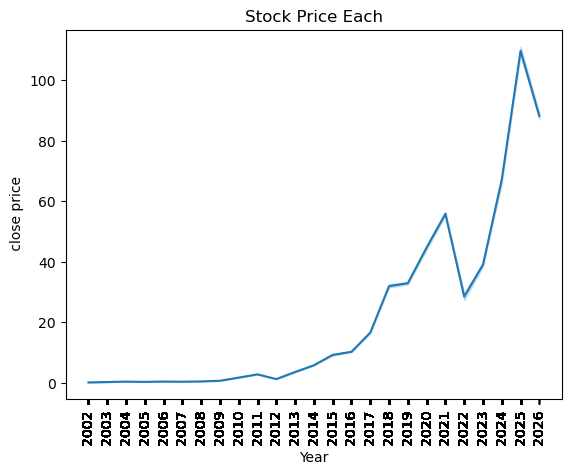

In [85]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.lineplot(
    x=data['Year'],
    y= data['Close'],
    data=data
)
plt.ylabel(" close price")
plt.title("Stock Price Each")
plt.xticks(data['Year'], rotation=90)  # show every year
plt.show()

yes, we can clearly see Netflix's massive growth from 2002 to 2026. 

early 10 years closing price is nearly 0 but now its closing price is about 100

Q24. Plot the 30-day and 90-day moving averages together with the actual Close price on the same line chart — use different colors for each line.


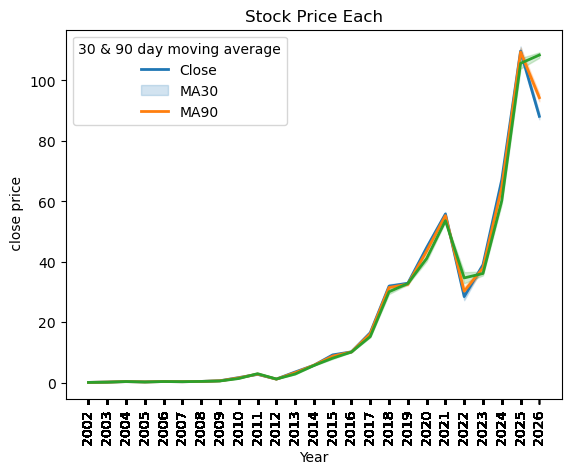

In [86]:
sns.lineplot(
    x=data['Year'],
    y= data['Close'],
    linewidth=2,
)
sns.lineplot(
    x=data['Year'],
    y=data['MA30'],
    linewidth=2,
)
sns.lineplot(
    x=data['Year'],
    y=data['MA90'],
    linewidth=2,
)
plt.ylabel(" close price")
plt.title("Stock Price Each")
plt.legend(title="30 & 90 day moving average", labels=["Close", "MA30", "MA90"])
plt.xticks(data['Year'], rotation=90)  # show every year
plt.show()

Another way to do the same as give below

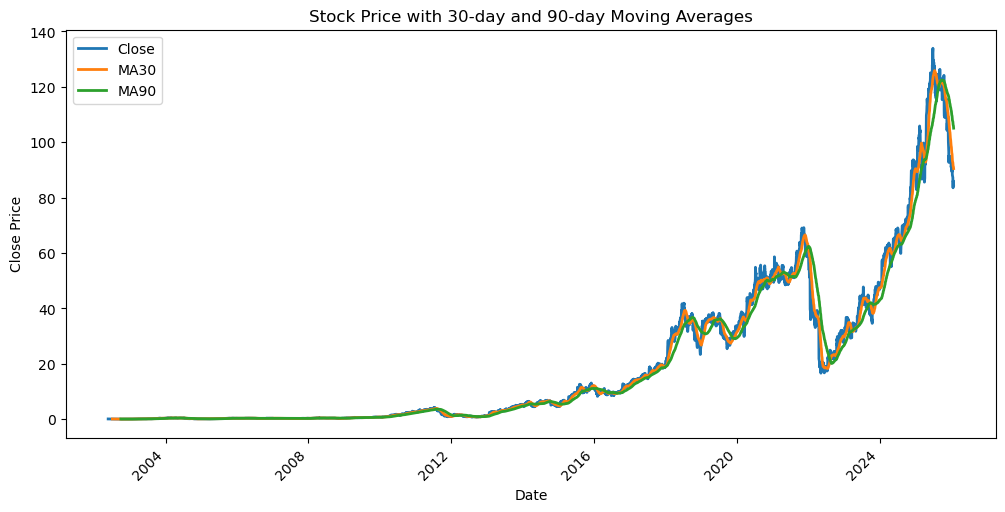

In [87]:
# Select the columns you want and plot them all at once
data[['Close', 'MA30', 'MA90']].plot(figsize=(12, 6), linewidth=2)

plt.title("Stock Price with 30-day and 90-day Moving Averages")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

Q25. Create a histogram of Daily Returns using sns.histplot() — is the distribution roughly normal or skewed?


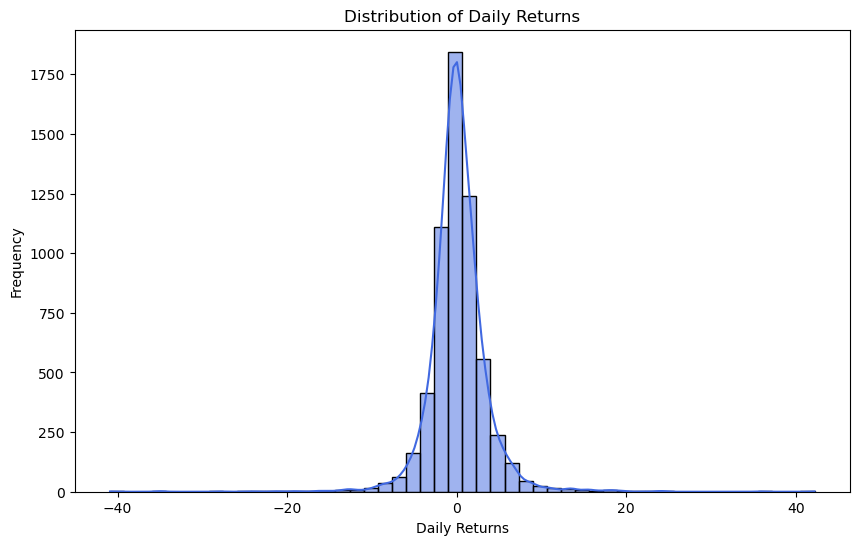

In [88]:
# Set a clean figure size
plt.figure(figsize=(10, 6))

# Create the histogram with a smooth density line
sns.histplot(data=data, x='Daily_Return', kde=True, bins=50, color='royalblue')

# Customize labels and title
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")

plt.show()

we have a symmetrical or normal distribution

Q26. Create a boxplot of the monthly Close prices grouped by month (Jan–Dec) using sns.boxplot() — which months tend to have higher prices?


<Axes: xlabel='Month', ylabel='Close'>

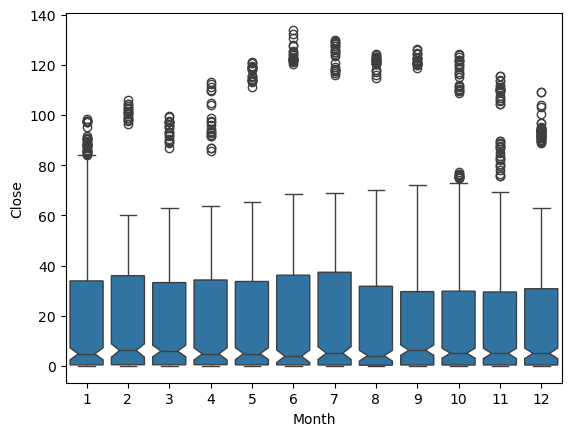

In [89]:
grouped_by_months=data.groupby('Month')
grouped_by_months.sample().sort_values(by="Month")

sns.boxplot(
    data=data,
    x=data['Month'],
    y=data['Close'],
    notch=True
)

we can see the highest price in two ways:-
1. Including outliers:- Month 6 (June) has the highest recorded price because it contains the highest outlier. June experienced some exceptionally high closing prices compared to the rest of the data. These could be considered price spikes or unusually strong trading days

2. Excluding outliers:-Months 9 and 10 appear to have the highest upper whiskers and relatively high distributions. If we ignore extreme price spikes and focus on the normal trading range, September and October tend to have the highest prices.

In [90]:
data.sample()

,Close,High,Low,Open,Volume,Year,Month,Day,Day of Week,Daily_Range,Daily_Return,Price_Direction,MA30,MA90,data_error,invalid_entries
Date,,,,,,,,,,,,,,,,
2006-12-29,0.369429,0.382857,0.369286,0.372286,69377000,2006,12,29,Friday,0.013571,-0.919391,Down,0.401405,0.359516,False,False


Q27. Create a countplot using sns.countplot() showing how many "Up" days vs "Down" days Netflix has had — is it more bullish or bearish overall?


/var/folders/d8/83r4k_r15tv7zl64z94ffs640000gn/T/ipykernel_14657/1835510855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


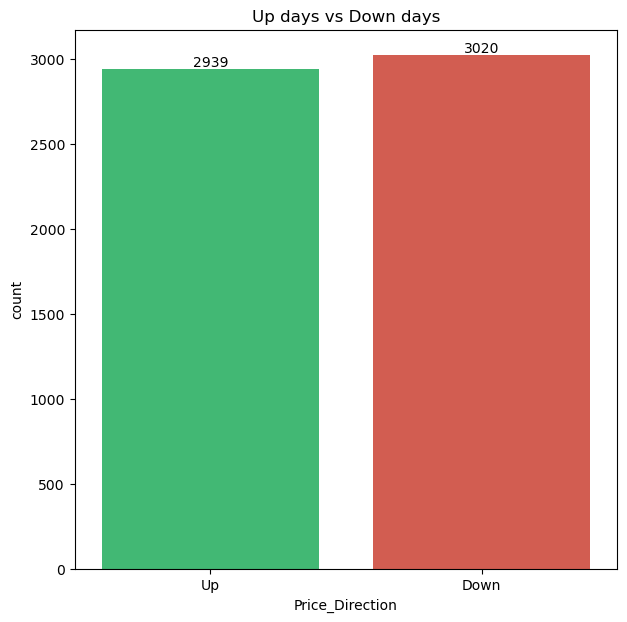

In [91]:
plt.figure(figsize=(7,7))
sns.countplot(
    data=data, 
    x=data['Price_Direction'], 
    palette=['#2ecc71', '#e74c3c']
    )

plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])

# for container in plt.gca().containers:   # another way to add the count on the top of the bar
#     plt.bar_label(container, padding=4)

plt.title("Up days vs Down days")
plt.show()

it is more bearish because the down trend is more then up trend.

Q28. Create a heatmap using sns.heatmap() showing the correlation between Close, High, Low, Open, and Volume — which columns are most correlated?


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5959 entries, 2002-05-23 to 2026-01-28
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            5959 non-null   float64
 1   High             5959 non-null   float64
 2   Low              5959 non-null   float64
 3   Open             5959 non-null   float64
 4   Volume           5959 non-null   int64  
 5   Year             5959 non-null   int32  
 6   Month            5959 non-null   int32  
 7   Day              5959 non-null   int32  
 8   Day of Week      5959 non-null   object 
 9   Daily_Range      5959 non-null   float64
 10  Daily_Return     5958 non-null   float64
 11  Price_Direction  5959 non-null   object 
 12  MA30             5930 non-null   float64
 13  MA90             5870 non-null   float64
 14  data_error       5959 non-null   bool   
 15  invalid_entries  5959 non-null   bool   
dtypes: bool(2), float64(8), int32(3), int64(1)

In [93]:
data = data.drop(columns=['Day of Week','Price_Direction'])
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5959 entries, 2002-05-23 to 2026-01-28
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            5959 non-null   float64
 1   High             5959 non-null   float64
 2   Low              5959 non-null   float64
 3   Open             5959 non-null   float64
 4   Volume           5959 non-null   int64  
 5   Year             5959 non-null   int32  
 6   Month            5959 non-null   int32  
 7   Day              5959 non-null   int32  
 8   Daily_Range      5959 non-null   float64
 9   Daily_Return     5958 non-null   float64
 10  MA30             5930 non-null   float64
 11  MA90             5870 non-null   float64
 12  data_error       5959 non-null   bool   
 13  invalid_entries  5959 non-null   bool   
dtypes: bool(2), float64(8), int32(3), int64(1)
memory usage: 547.0 KB


In [94]:
data.corr()

,Close,High,Low,Open,Volume,Year,Month,Day,Daily_Range,Daily_Return,MA30,MA90,data_error,invalid_entries
Close,1.000000,0.999894,0.999902,0.999757,-0.309796,0.808619,0.020709,0.000588,0.840505,-0.007329,0.996339,0.986957,NaN,NaN
High,0.999894,1.000000,0.999864,0.999883,-0.309153,0.809439,0.020275,0.000444,0.845277,-0.011311,0.996613,0.987362,NaN,NaN
Low,0.999902,0.999864,1.000000,0.999882,-0.310625,0.807892,0.021225,0.000910,0.836340,-0.011053,0.996353,0.986871,NaN,NaN
Open,0.999757,0.999883,0.999882,1.000000,-0.309861,0.808553,0.020781,0.000639,0.840804,-0.015137,0.996609,0.987259,NaN,NaN
Volume,-0.309796,-0.309153,-0.310625,-0.309861,1.000000,-0.219564,-0.046474,0.031705,-0.212338,-0.011095,-0.309548,-0.312964,NaN,NaN
Year,0.808619,0.809439,0.807892,0.808553,-0.219564,1.000000,-0.038719,-0.003390,0.730690,-0.010575,0.809065,0.812146,NaN,NaN
Month,0.020709,0.020275,0.021225,0.020781,-0.046474,-0.038719,1.000000,-0.002320,-0.013705,-0.020368,0.022399,0.027884,NaN,NaN
Day,0.000588,0.000444,0.000910,0.000639,0.031705,-0.003390,-0.002320,1.000000,-0.014707,0.009971,0.001141,0.002209,NaN,NaN
Daily_Range,0.840505,0.845277,0.836340,0.840804,-0.212338,0.730690,-0.013705,-0.014707,1.000000,-0.017878,0.846078,0.844990,NaN,NaN
Daily_Return,-0.007329,-0.011311,-0.011053,-0.015137,-0.011095,-0.010575,-0.020368,0.009971,-0.017878,1.000000,-0.020035,-0.024279,NaN,NaN


<Axes: >

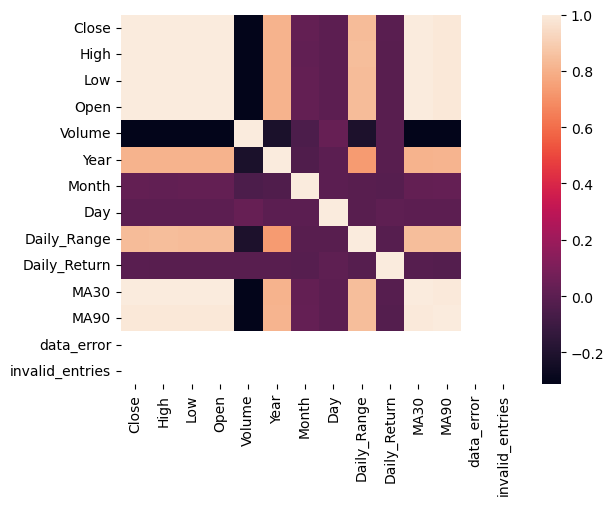

In [95]:
sns.heatmap(data.corr())

1.Most strongly correlated columns

The lightest-colored cells (excluding the diagonal) are:

Close ↔ High, Close ↔ Low, Close ↔ Open, High ↔ Low, High ↔ Open, Low ↔ Open, Close ↔ MA30, Close ↔ MA90, MA30 ↔ MA90,

These appear to have correlations close to +1, indicating a very strong positive relationship.

2.Strong negative correlation

The darkest cells are between:

Volume ↔ Close, Volume ↔ High, Volume ↔ Low, Volume ↔ Open, Volume ↔ MA30, Volume ↔ MA90

These appear to have a moderate negative correlation (around -0.2 to -0.3 from the color scale).

Q29. Create a bar chart showing the average yearly trading Volume from 2002 to 2026 using sns.barplot() — in which years was Netflix most actively traded?


Text(0.5, 1.0, 'Average Yearly Trading Volume for Netflix (2002-2026)')

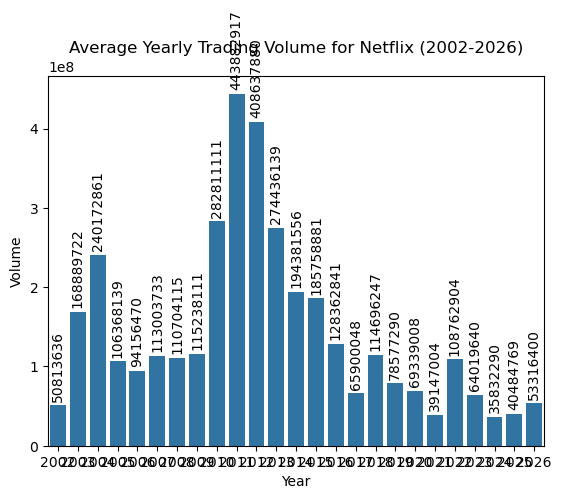

In [96]:
sns.barplot(
    data=data,
    x=data['Year'],
    y=data['Volume'],
    errorbar=None
)
plt.bar_label(plt.gca().containers[0],fmt='%.0f',rotation=90,padding=3)
plt.title("Average Yearly Trading Volume for Netflix (2002-2026)")

in 2011 Netflix stocks was most activelly traded.


Q30. Create a pair plot using sns.pairplot() for Close, Volume, Daily_Return, and Daily_Range — do you notice any interesting relationships between these variables?


In [97]:
data.sample()

,Close,High,Low,Open,Volume,Year,Month,Day,Daily_Range,Daily_Return,MA30,MA90,data_error,invalid_entries
Date,,,,,,,,,,,,,,
2020-04-07,37.228001,38.132999,36.933998,38.0,70464000,2020,4,7,1.199001,-2.02126,35.603533,34.466244,False,False


In [98]:
data.drop(columns=['data_error','invalid_entries'],inplace=True)

In [99]:
data.sample()

,Close,High,Low,Open,Volume,Year,Month,Day,Daily_Range,Daily_Return,MA30,MA90
Date,,,,,,,,,,,,
2018-10-11,32.110001,33.419998,31.580999,32.493999,160821000,2018,10,11,1.838999,-1.469821,36.104233,36.719578


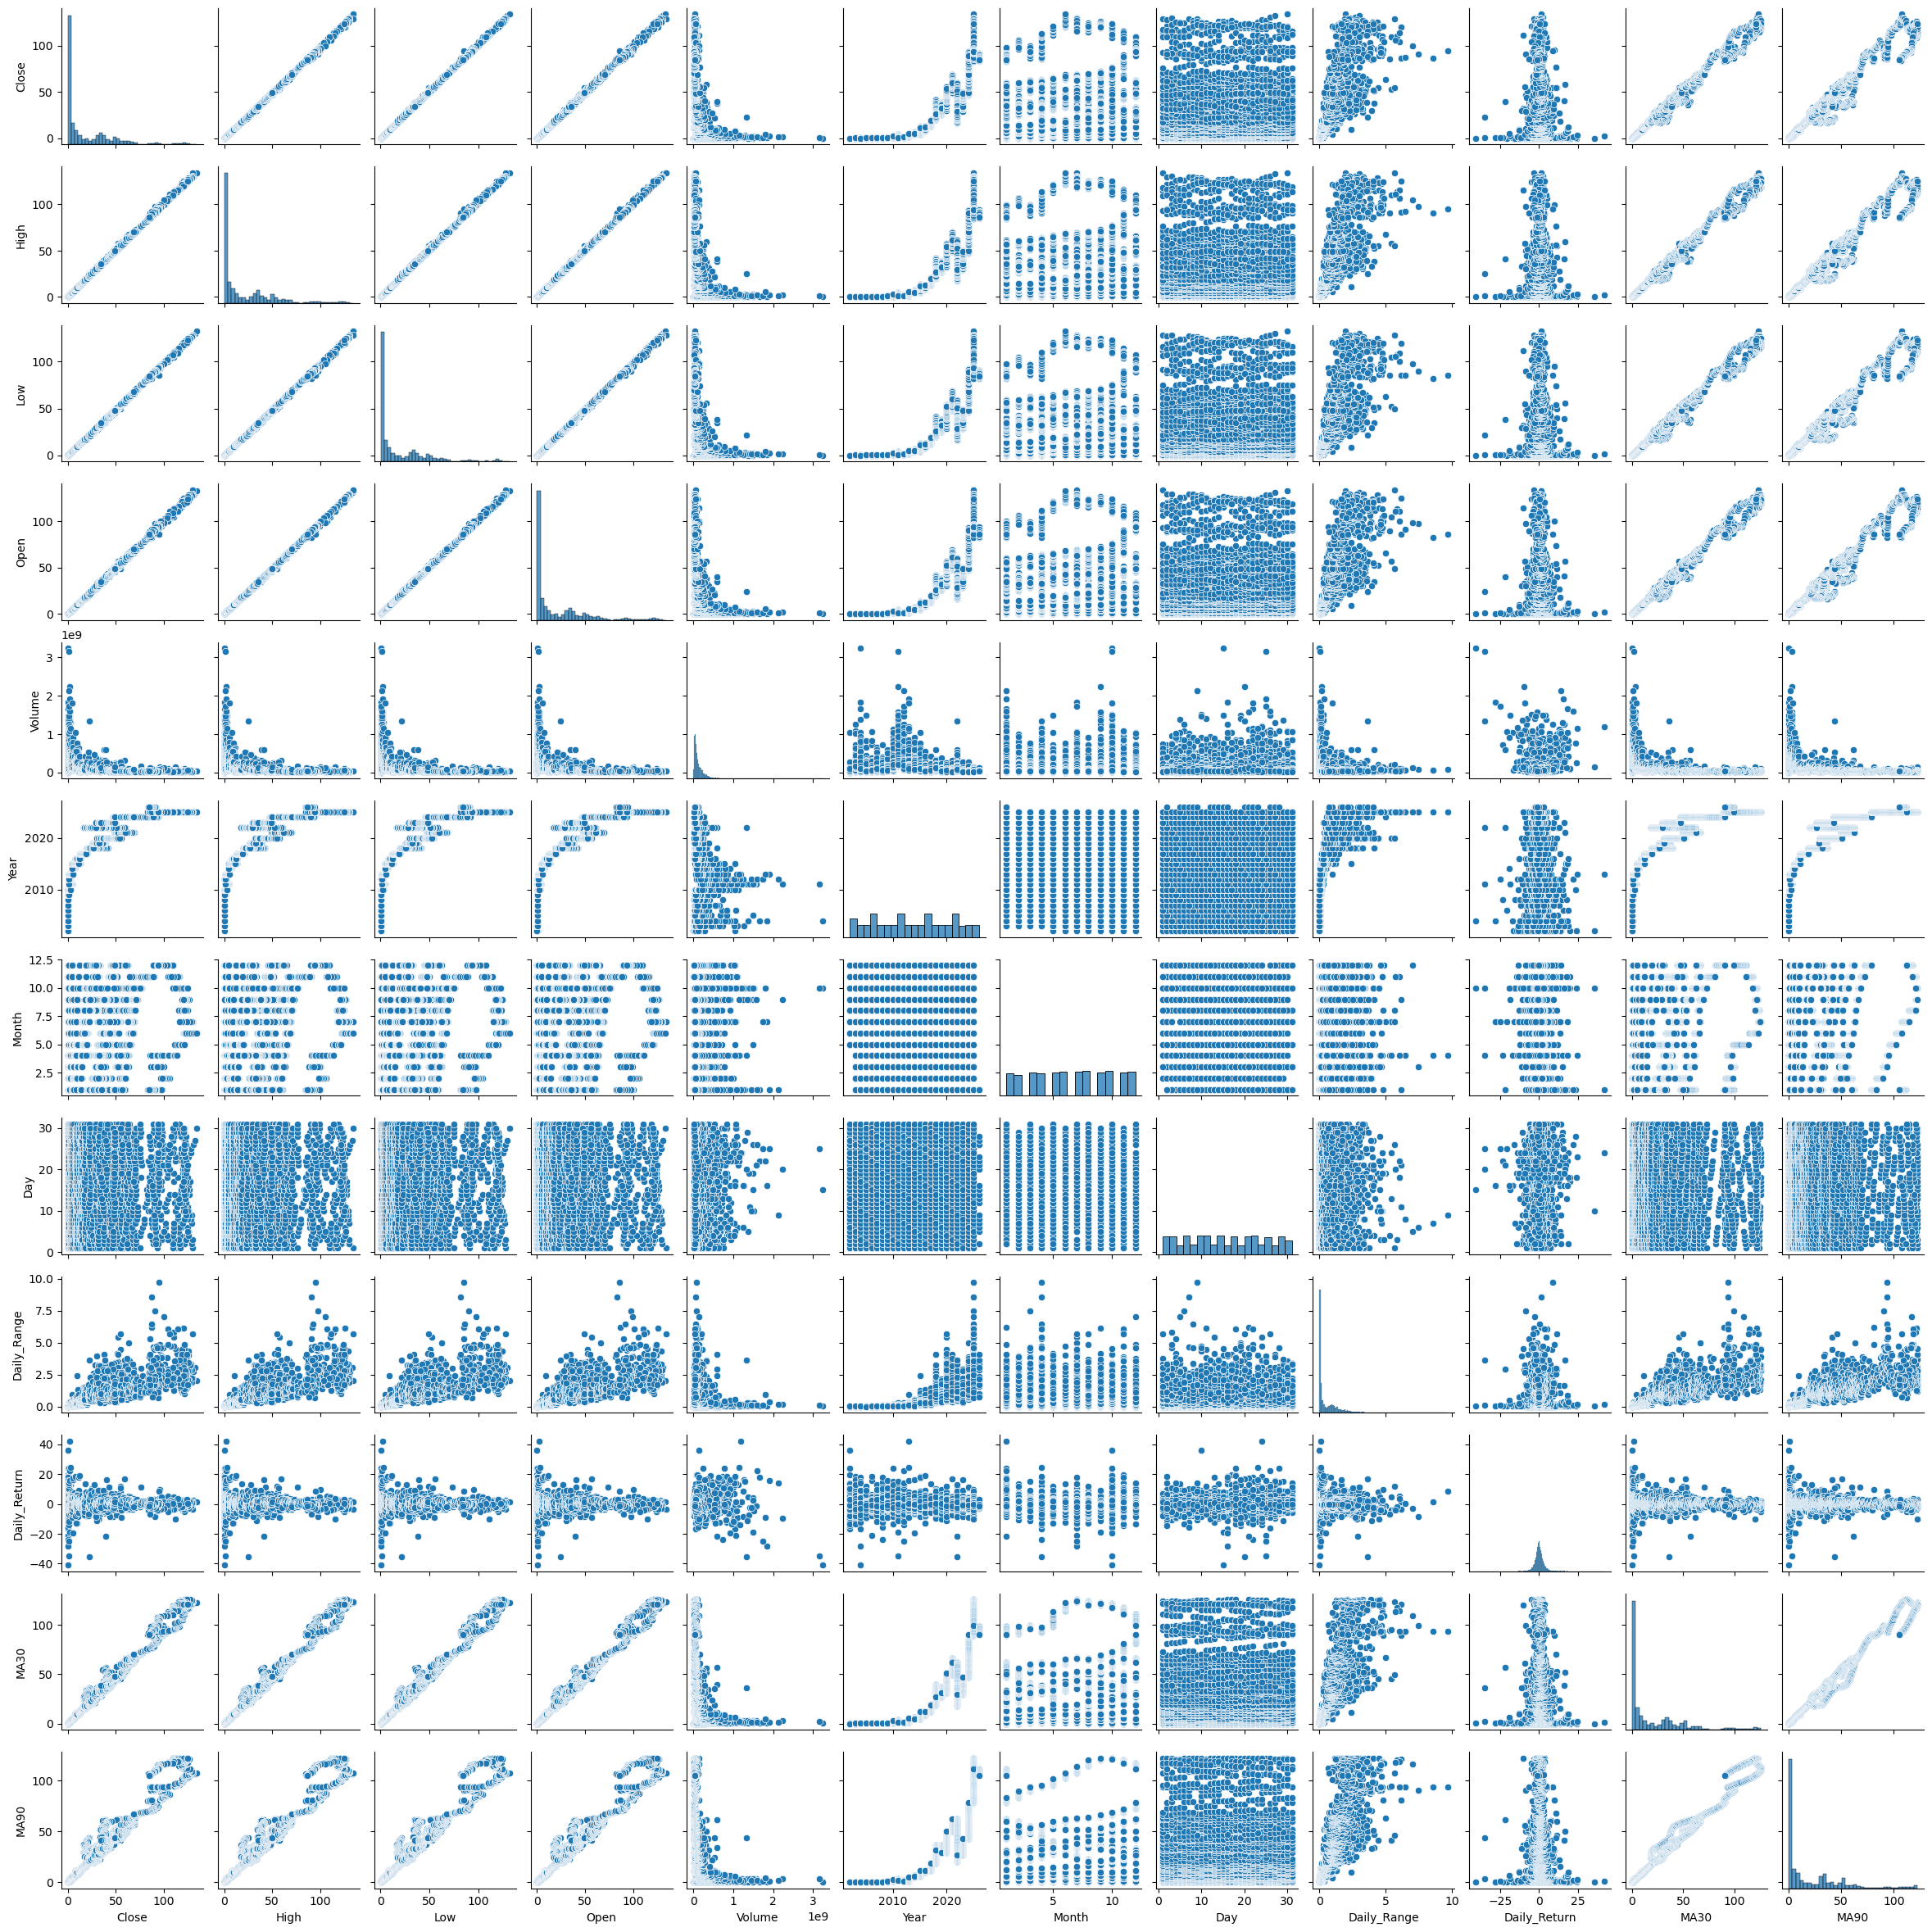

In [100]:
sns.pairplot(data,height=2)

5 Bonus Questions to Add

Q31. Calculate the yearly return for each year — which year was Netflix's best and worst performing year percentage-wise?

In [101]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Month', 'Day',
       'Daily_Range', 'Daily_Return', 'MA30', 'MA90'],
      dtype='object')

In [102]:
yearly_return = data.groupby('Year')['Daily_Return'].apply(
    lambda x: ((1 + x).prod() - 1) * 100
)
print(yearly_return)
best_year = yearly_return.idxmax()
worst_year = yearly_return.idxmin()

print("Best Year:", best_year)
print("Return:", yearly_return.max(), "%")

print("Worst Year:", worst_year)
print("Return:", yearly_return.min(), "%")

Year
2002   -9.746163e+66
2003   -1.779150e+85
2004    9.125984e+59
2005    1.656361e+49
2006   -4.817895e+22
2007   -8.977801e+26
2008   -2.025928e+78
2009    1.157186e+42
2010   -5.609781e+61
2011    1.978841e+56
2012   -1.754323e+53
2013    3.170966e+38
2014    9.170192e+13
2015    1.758029e+27
2016    8.665769e+25
2017    1.926355e+06
2018   -1.485477e+41
2019   -8.180247e+16
2020    1.776363e+46
2021   -2.927886e+06
2022    3.108160e+59
2023   -3.288049e+24
2024   -1.604425e+08
2025   -2.717996e+25
2026   -9.985239e+01
Name: Daily_Return, dtype: float64
Best Year: 2004
Return: 9.125983536583431e+59 %
Worst Year: 2003
Return: -1.7791497289386694e+85 %


Q32. Find the exact date of Netflix's all-time high and all-time low Close price — what were the prices on those dates?

In [103]:
data['Date'] = pd.to_datetime(
    data[['Year', 'Month', 'Day']]
)

high_row = data.loc[data['Close'].idxmax()]
low_row = data.loc[data['Close'].idxmin()]

print("All-Time High")
print("Date:", high_row['Date'])
print("Close:", high_row['Close'])

print("\nAll-Time Low")
print("Date:", low_row['Date'])
print("Close:", low_row['Close'])

All-Time High
Date: 2025-06-30 00:00:00
Close: 133.91299438476562

All-Time Low
Date: 2002-10-09 00:00:00
Close: 0.0372859984636306


Q33. Calculate the yearly standard deviation of daily returns — which year was Netflix most volatile and which was most stable?

data.groupby('Year')['Daily_Return']

In [104]:
yearly_volatility = data.groupby('Year')['Daily_Return'].std()

print("Most Volatile Year:", yearly_volatility.idxmax())
print("Most Stable Year:", yearly_volatility.idxmin())

Most Volatile Year: 2002
Most Stable Year: 2026


Q34. Plot a line chart showing Netflix's 2022 crash and recovery — filter data from 2021 to 2024 and annotate the peak and bottom points.

<Axes: xlabel='Date', ylabel='Close'>

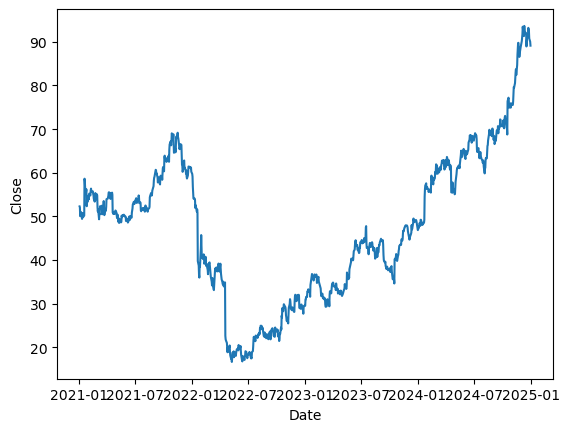

In [105]:
# Filter data from 2021 to 2024
filtered_data = data[(data['Year'] >= 2021) & (data['Year'] <= 2024)]

# Plot the Close price over time.
sns.lineplot(
    data=filtered_data,
    x=filtered_data.index,
    y=filtered_data['Close']
)

 in the Netflix's 2022 crash and recovery the peak point is about 70 and the bottom point is below 20.

Q35. Create a scatter plot using sns.scatterplot() of Volume vs Daily_Return — is there a pattern between how much trading happens and whether price goes up or down?


Text(0.5, 1.0, 'Volume VS Daily_Return')

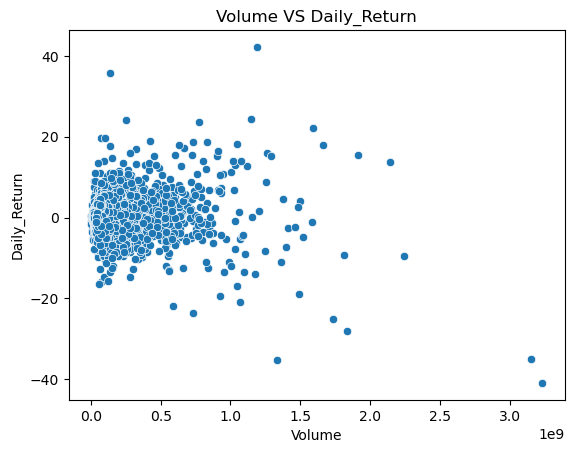

In [106]:
sns.scatterplot(
    data=data,
    x=data['Volume'],
    y=data['Daily_Return'],
)
plt.title("Volume VS Daily_Return")

No, there is no direct pattern showing whether a high trading volume causes the price to go up or go down.

!!!!! Completed!!!!!